# Natural Language Processing

## Dataset: The Multilingual Amazon Reviews Corpus

This project is available in this [repository](https://gitlab.com/ricardoleoncorreia/amazon-review-score-predictor) in GitLab.

Details about the dataset:
* It can be downloaded [here](https://github.com/kang205/SASRec).
* [Description](https://registry.opendata.aws/amazon-reviews-ml/).
* [License](https://docs.opendata.aws/amazon-reviews-ml/license.txt)

Let's import all necessary libraries, define constansts and functions for the analysis:

In [44]:
sys.path.append(os.path.abspath('..'))  # Add project root to Python path

import sys, os
import importlib
from amazon_review_score_predictor import plot
from amazon_review_score_predictor import transform
from amazon_review_score_predictor import time

importlib.reload(transform)
importlib.reload(plot)
importlib.reload(time)

from amazon_review_score_predictor.plot import PlotUtils
from amazon_review_score_predictor.transform import *


In [4]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
import spacy

# from time import time
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

random_state = 2021-1-30
fontsize = 16
base_sample = 10000
max_features = 2000
nlp = spacy.load("es_core_news_sm")

Import training data and print the first 5 rows:

In [5]:
reviews_train_data = pd.read_csv("../data/interim/train.csv")
reviews_train_data.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics
1,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics
2,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore
3,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless
4,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes


### Exploratory Data Analysis

There are no null values and the only numeric column is the review stars.

A bar plot will help to visualize the type of the problem:

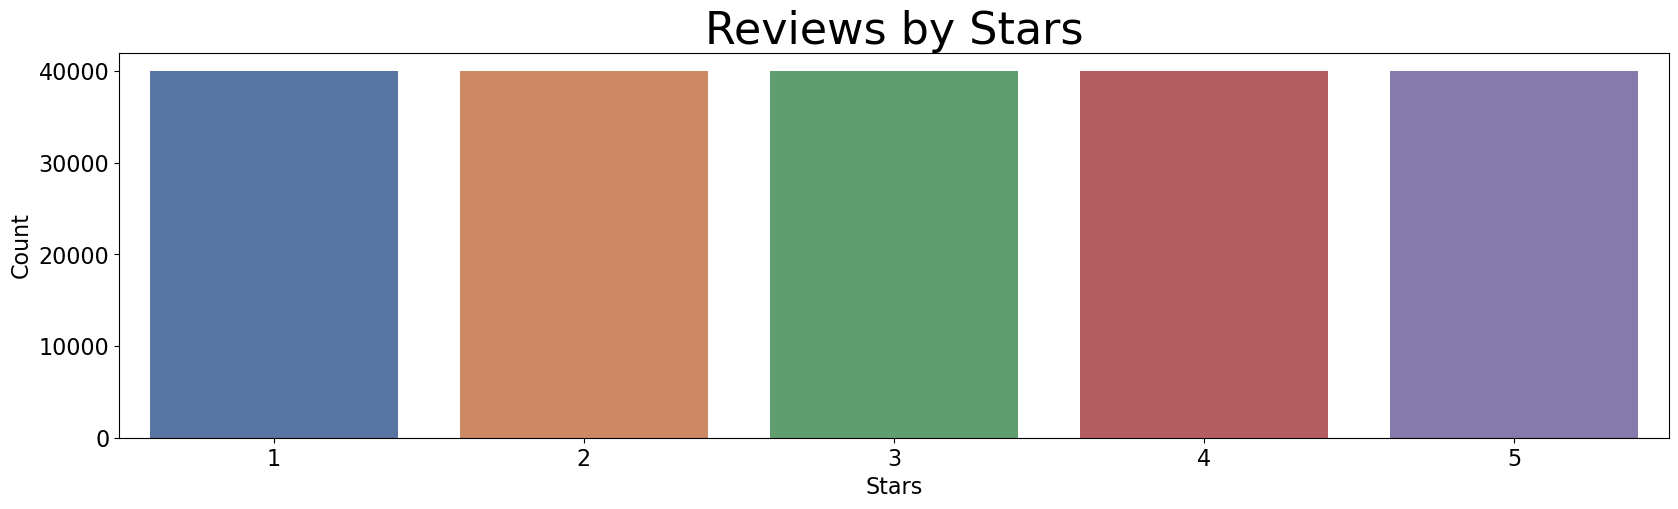

In [11]:
from amazon_review_score_predictor.plot import PlotUtils

PlotUtils.create_plot(
  type="count",
  x="stars",
  hue="stars",
  data=reviews_train_data,
  palette="deep",
  title="Reviews by Stars",
  xlabel="Stars",
  ylabel="Count"
)

From the previous figure, it can be seen that it is a **multi-class classification** problem. 

The following plot will provide a better understanding about the context of the data:

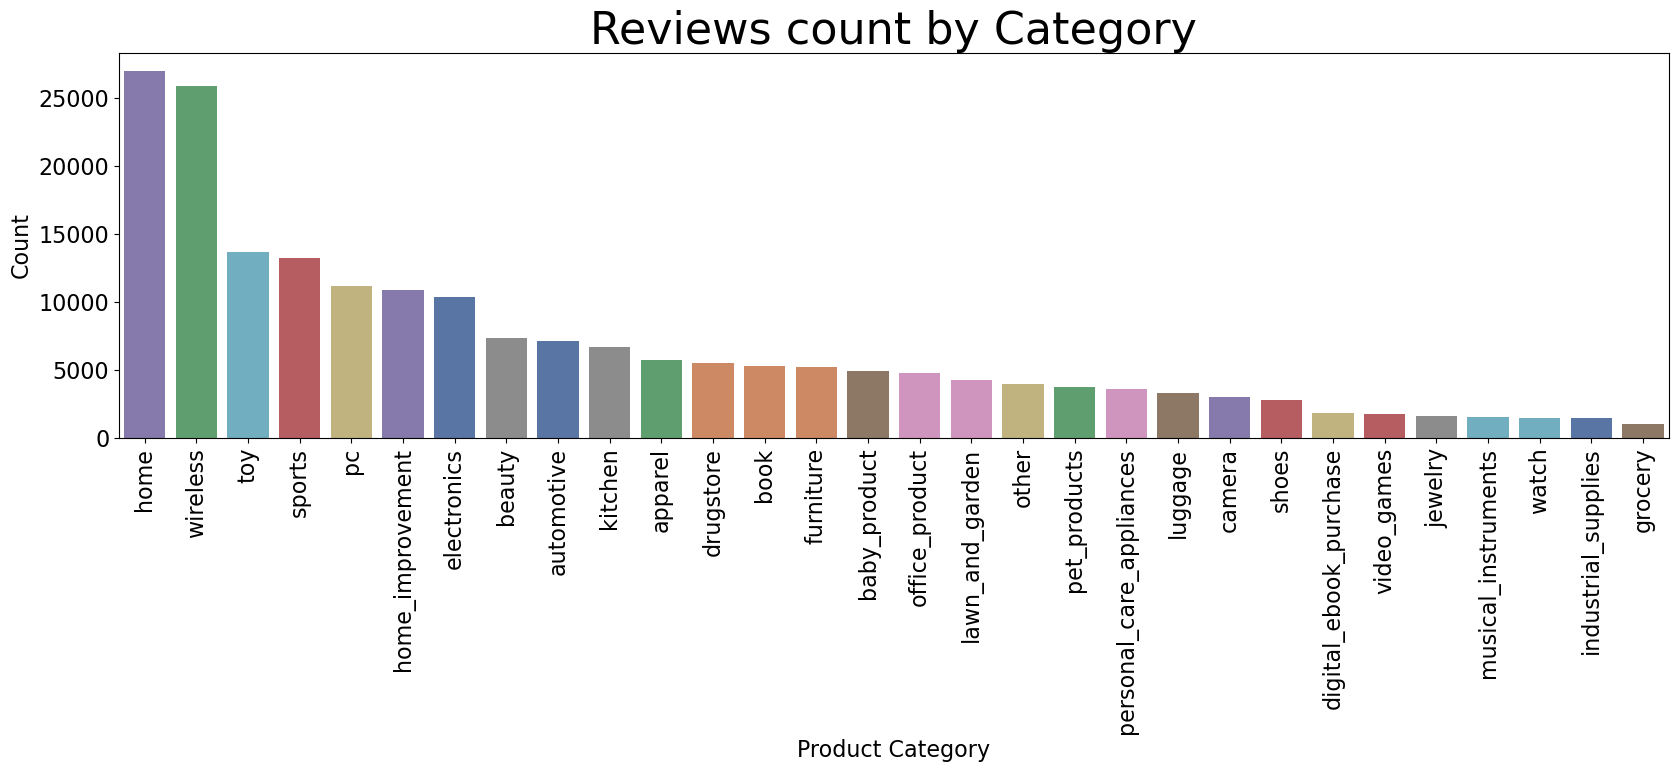

In [12]:
PlotUtils.create_plot(
  type="count",
  x="product_category",
  hue="product_category",
  data=reviews_train_data,
  order=reviews_train_data["product_category"].value_counts().index,
  title="Reviews count by Category",
  xlabel="Product Category",
  ylabel="Count",
  xtick_rotation=90
)

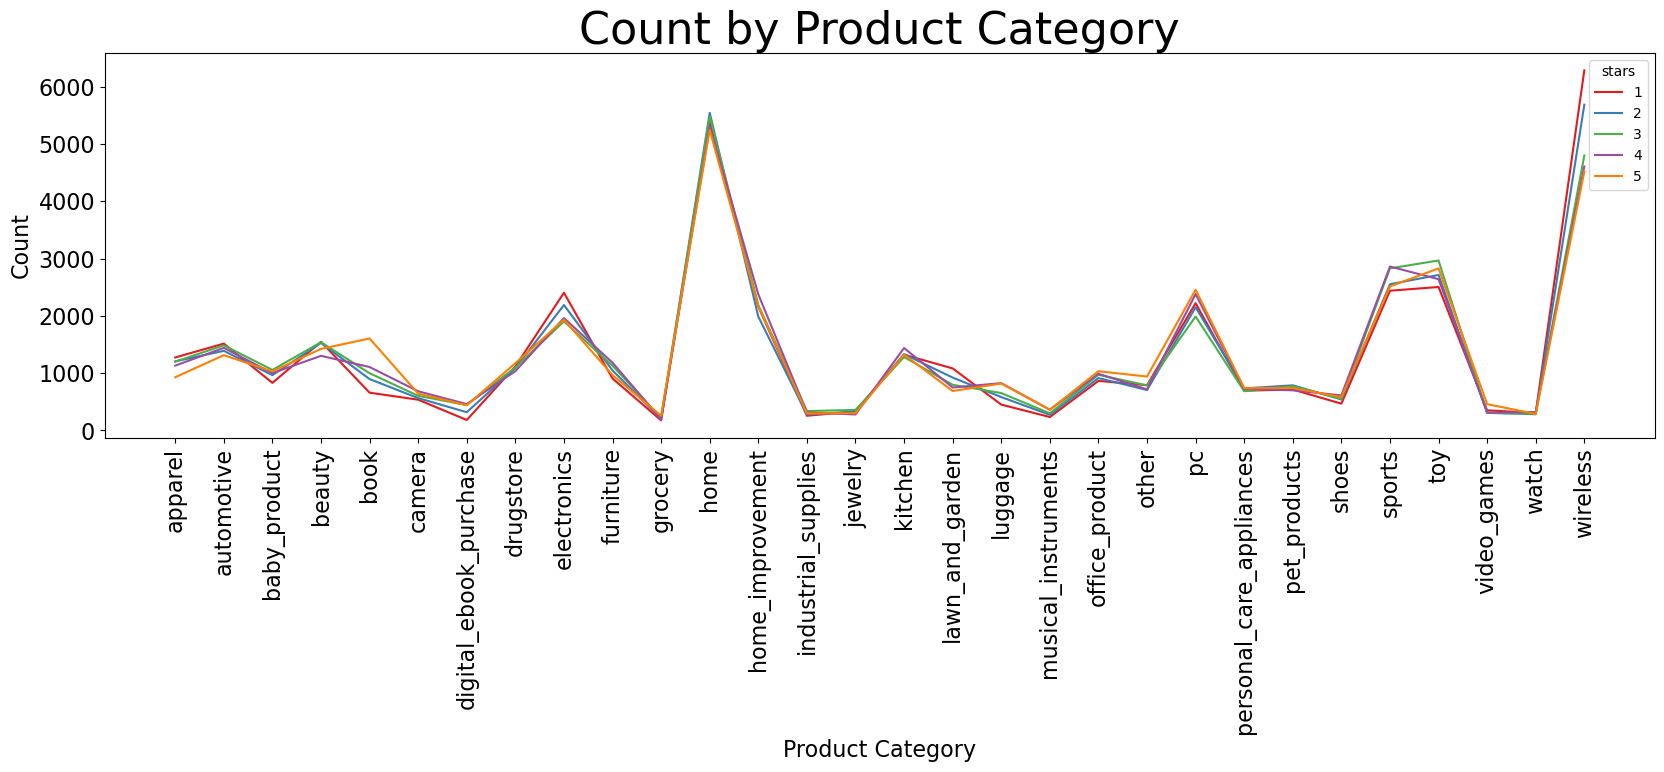

In [13]:
reviews_count = reviews_train_data[["product_category", "stars"]]\
                    .groupby(["product_category", "stars"])["product_category"]\
                    .count()\
                    .reset_index(name="count")\
                    .copy()

PlotUtils.create_plot(
  type="line",
  data=reviews_count,
  x="product_category",
  y="count",
  hue="stars",
  title="Count by Product Category",
  xlabel="Product Category",
  ylabel="Count",
  palette="Set1",
  xtick_rotation=90,
  legend=True
)

`Home` and `Wireless` are the most frequent categories, however, the frequency patters across all categories are similar.

Some extra information about the data:

In [14]:
print(f"Unique languages: {reviews_train_data.language.nunique()}")
print(f"Unique products: {reviews_train_data.product_id.nunique()} ({100 * reviews_train_data.product_id.nunique() / reviews_train_data.shape[0]}%)")
print(f"Unique reviewer: {reviews_train_data.reviewer_id.nunique()} ({100 * reviews_train_data.reviewer_id.nunique() / reviews_train_data.shape[0]}%)")

Unique languages: 1
Unique products: 150938 (75.469%)
Unique reviewer: 179076 (89.538%)


At the end, it can be seen that:

* `Homeless` y `Wireless` are the categories with more rows.
* The quantity of review stars is balanced across the categories.
* Mostly all the reviews correspond to unique users and products.

Let's set the seed (for reproducibility) to analyze the text in one review body:

In [15]:
np.random.seed(random_state)
random_index = np.random.randint(reviews_train_data.shape[0])
reviews_train_data.iloc[random_index]

review_id                                                  es_0018170
product_id                                         product_es_0239974
reviewer_id                                       reviewer_es_0518937
stars                                                               1
review_body         La primera vez que la metí en el lavavajillas ...
review_title                                   Lo barato sale caro...
language                                                           es
product_category                                               sports
Name: 9162, dtype: object

In [16]:
random_review_body = reviews_train_data.review_body[random_index]
random_review_body

'La primera vez que la metí en el lavavajillas con un programa de 50 grados, se deformó. Ya antes se había partido el asa con tan solo unos días de uso.'

Create a `spaCy` document to handle the text:

In [17]:
doc = nlp(random_review_body)
print(doc.text)

La primera vez que la metí en el lavavajillas con un programa de 50 grados, se deformó. Ya antes se había partido el asa con tan solo unos días de uso.


Listing the sentences and tokens generated by the library:

In [18]:
for sentence in doc.sents:
    print(sentence)

La primera vez que la metí en el lavavajillas con un programa de 50 grados, se deformó.
Ya antes se había partido el asa con tan solo unos días de uso.


In [19]:
tokenized_review_body = [token for token in doc]
print(tokenized_review_body)

[La, primera, vez, que, la, metí, en, el, lavavajillas, con, un, programa, de, 50, grados, ,, se, deformó, ., Ya, antes, se, había, partido, el, asa, con, tan, solo, unos, días, de, uso, .]


`spaCy` has a `Lemmatisation` implementation so this process is the one that is going to be used in this analysis.

Below, it is going to be shown the results of the lemmatisation process together with the original tokens:

In [20]:
for token in doc:
    # Get the token text, part-of-speech tag and dependency label
    token_text = token.text
    token_lemma = token.lemma_
    token_pos = token.pos_
    token_dep = token.dep_
    token_explanation = spacy.explain(token_pos)
    print(f"{token_text:<13}{token_lemma:<13}{token_pos:<10}{token_dep:<10}{token_explanation}")

La           el           DET       det       determiner
primera      primero      ADJ       amod      adjective
vez          vez          NOUN      obl       noun
que          que          PRON      obl       pronoun
la           él           PRON      obj       pronoun
metí         meter        VERB      acl       verb
en           en           ADP       case      adposition
el           el           DET       det       determiner
lavavajillas lavavajilla  NOUN      obl       noun
con          con          ADP       case      adposition
un           uno          DET       det       determiner
programa     programa     NOUN      obl       noun
de           de           ADP       case      adposition
50           50           NUM       nummod    numeral
grados       grado        NOUN      nmod      noun
,            ,            PUNCT     punct     punctuation
se           él           PRON      expl:pv   pronoun
deformó      deformar     VERB      ROOT      verb
.            .        

Excluding all `stop words` and punctuation signs:

In [21]:
for token in doc:
    if token.is_stop or token.is_punct:
        continue
    # Get the token text, part-of-speech tag and dependency label
    token_text = token.text
    token_pos = token.pos_
    token_dep = token.dep_
    token_lemma = token.lemma_
    token_explanation = str(spacy.explain(token_pos))
    print(f"{token_text:<13}{token_lemma:<13}{token_pos:<10}{token_dep:<10}{token_explanation}")

metí         meter        VERB      acl       verb
lavavajillas lavavajilla  NOUN      obl       noun
programa     programa     NOUN      obl       noun
50           50           NUM       nummod    numeral
grados       grado        NOUN      nmod      noun
deformó      deformar     VERB      ROOT      verb
partido      partir       VERB      ROOT      verb
asa          asa          PROPN     nsubj     proper noun


The quantity of words is reduced. However, there are some words (numbers in this case) that have less than three characters. To reduce the probability that a undesired word can avoid the filter, all tokens with less than 4 characters are going to be discarded.

The following function is a summary of the filtering process described above:

The final result is the following:

In [22]:
from amazon_review_score_predictor.transform import NLPUtils
NLPUtils.lemmatize_text(nlp, text=random_review_body, exceptions=["no"])

'meter lavavajilla programa grado deformar partir'

**Note:**

The word `no` was included as an exception to the filtering. It can be important to differenciate positive and negative reviews. The next cell will illustrate why it was included. Two titles `El producto fue recibido` and `El producto no fue recibido` are going to be compared after the raw lemmatisation process:

In [23]:
original_negative_text = "El producto no fue recibido"
original_positive_text = "El producto fue recibido"
print(f"Negative text: {original_negative_text} => {NLPUtils.lemmatize_text(nlp, original_negative_text)}")
print(f"Positive text: {original_positive_text} => {NLPUtils.lemmatize_text(nlp, original_positive_text)}")

Negative text: El producto no fue recibido => producto recibir
Positive text: El producto fue recibido => producto recibir


N-grams can provide more information about the content (and differenciate it from others). The following method will be used in a couple of cells later to visualize the most frequent bigrams and trigrams.

In [131]:
# def common_words_count(df, stars, ngram_range, max_count=40, fontsize=fontsize, figsize=(15, 8)):
#   # Filter the Dataset and create the count vectorizer
#     data_to_study = df.copy()[df.stars.isin(stars)]
#     count_vectorizer = CountVectorizer(ngram_range=ngram_range)
#     fig, axes = plt.subplots(1, 2, figsize=figsize)
#     fig.suptitle(f"Most frequent words for reviews with {stars} stars", fontsize=fontsize)

#     # Title
#     body_words_count = count_vectorizer.fit_transform(data_to_study.review_title)
#     count_per_word = body_words_count.toarray().sum(axis=0)
#     index_order = np.argsort(-count_per_word)
#     body_words_labels = np.array(count_vectorizer.get_feature_names_out())[index_order][0:max_count]
#     count_per_word = count_per_word[index_order][0:max_count]
#     g = sns.barplot(x=body_words_labels,hue=body_words_labels,y=count_per_word, ax=axes[0])
#     g.set_xlabel("n-grams", fontsize=fontsize)
#     g.set_ylabel("Count", fontsize=fontsize)
#     g.tick_params(labelsize=fontsize, labelrotation=90)
#     axes[0].set_title("Most common n-grams in the title")
    
#     # Body
#     body_words_count = count_vectorizer.fit_transform(data_to_study.review_body)
#     count_per_word = body_words_count.toarray().sum(axis=0)
#     index_order = np.argsort(-count_per_word)
#     body_words_labels = np.array(count_vectorizer.get_feature_names_out())[index_order][0:max_count]
#     count_per_word = count_per_word[index_order][0:max_count]
#     g = sns.barplot(x=body_words_labels,hue=body_words_labels,y=count_per_word, ax=axes[1])
#     g.set_xlabel("n-grams", fontsize=fontsize)
#     g.set_ylabel("Count", fontsize=fontsize)
#     g.tick_params(labelsize=fontsize, labelrotation=90)
#     axes[1].set_title("Most common n-grams in the body")
    
#     plt.show()

It will proceed to:

* Lemmatize the training data (both title and body of the review).
* Sample 10,000 reviews to:
   * Create the Benchmark model to create a starting point.
   * Re-conduct the study and training with more complete data.
   * Optimize the hyperparameters.
* Once the hyperparameter optimization phase is completed, a model with all the training data will be trained with this result.

**Note:** The reason why this procedure is performed this way is due to the computational cost that it entails. Taking a representative sample can help to perform a greater number of iterations to find the best possible hyperparameters. It was decided to be `10,000` to keep a 2-1 relationship with the dev dataset (total of` 5,000`).

In [155]:
# from amazon_review_score_predictor.time import TimeUtils
# import time

# class SlowUtils:
#     @staticmethod
#     def slow_function(num: int):
#         print("Starting...")
#         time.sleep(num)  # Pausa de 3 segundos
#         print(f"Waiting for {num} secs")
#         return "Done"

# TimeUtils.calculate_time(SlowUtils.slow_function, 30)

Starting...
Waiting for 30 secs
0.50 min


'Done'

In [52]:
from amazon_review_score_predictor.time import TimeUtils
from pathlib import Path
from time import time

lemmatizer = lambda text: NLPUtils.lemmatize_text(nlp, text, exceptions=["no"])

if Path('../data/processed/train.csv').is_file():
  reviews_train_data = pd.read_csv("../data/processed/train.csv")
else:
  print("Body lemmatization process:", end=" ")
  start_time = time()
  reviews_train_data.review_body = reviews_train_data.review_body.apply(lemmatizer)
  TimeUtils.print_elapsed_minutes(start_time)

  print("Title lemmatization process:", end=" ")
  start_time = time()
  reviews_train_data.review_title = reviews_train_data.review_title.apply(lemmatizer)
  TimeUtils.print_elapsed_minutes(start_time)

  reviews_train_data.to_csv("../data/processed/train.csv", index=False)

# weights = np.ones(reviews_train_data.shape[0])
# sampled_reviews_train_data = reviews_train_data.sample(n=base_sample, weights=weights, random_state=random_state)
# sampled_reviews_train_data = sampled_reviews_train_data[["review_title", "review_body", "stars"]]
# print(f"Size of the sample: {sampled_reviews_train_data.shape}")

# g = sns.countplot(x="stars", data=sampled_reviews_train_data)
# g.set_xlabel("Stars", fontsize=fontsize)
# g.set_ylabel("Count", fontsize=fontsize)
# plt.show()

# sampled_reviews_train_data.head()

Body lemmatization process: 36.18 min
Title lemmatization process: 20.52 min


In [48]:
reviews_train_data.review_title

0                                          television Nevir
1                 Dinero tirado a la basura con esta compra
2         solo llega una unidad cuando te obligan a comp...
3                                     PRODUCTO NO RECIBIDO.
4                                                  Devuelto
                                ...                        
199995                               Tal y como se describe
199996                               Funciona perfectamente
199997                                       Buena calidad.
199998                                          Recomendado
199999                                            Preciosas
Name: review_title, Length: 200000, dtype: object

In [49]:
reviews_train_data.review_body

0         Nada bueno se me fue ka pantalla en menos de 8...
1         Horrible, nos tuvimos que comprar otro porque ...
2         Te obligan a comprar dos unidades y te llega s...
3         No entro en descalificar al vendedor, solo pue...
4                      Llega tarde y co la talla equivocada
                                ...                        
199995    Mando funciona perfectamente y cumple con toda...
199996    Compré la batería con cierta reticencia, pero ...
199997             Buena calidad. Satisfecha con la compra.
199998                   Perfecto para el cumple de mi hijo
199999    Súper bien! Las brochas son buenas, no sé meno...
Name: review_body, Length: 200000, dtype: object

In [25]:
# Lemmatize
# print("Body process:", end=" ")
# start_time = time()
# reviews_train_data.review_body = reviews_train_data.review_body.apply(lemmatize_text)
# print_elapsed_minutes(start_time)

# print("Title process:", end=" ")
# start_time = time()
# reviews_train_data.review_title = reviews_train_data.review_title.apply(lemmatize_text)
# print_elapsed_minutes(start_time)

# weights = np.ones(reviews_train_data.shape[0])
# sampled_reviews_train_data = reviews_train_data.sample(n=base_sample, weights=weights, random_state=random_state)
# sampled_reviews_train_data = sampled_reviews_train_data[["review_title", "review_body", "stars"]]
# print(f"Size of the sample: {sampled_reviews_train_data.shape}")

# g = sns.countplot(x="stars", data=sampled_reviews_train_data)
# g.set_xlabel("Stars", fontsize=fontsize)
# g.set_ylabel("Count", fontsize=fontsize)
# plt.show()

In [24]:
# reviews_train_data.to_csv("../data/processed/train.csv", index=False)
# reviews_train_data.head()

Size of the sample: (10000, 3)


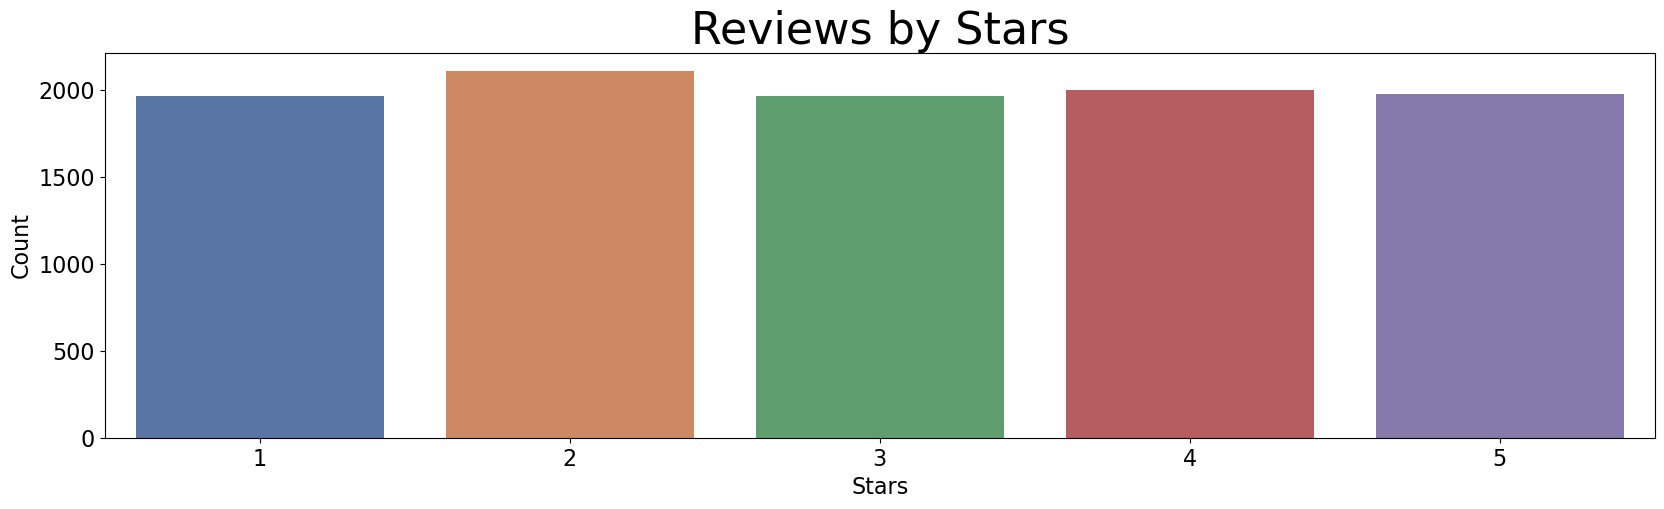

In [28]:
# reviews_train_data = pd.read_csv("../data/processed/train.csv")

weights = np.ones(reviews_train_data.shape[0])
sampled_reviews_train_data = reviews_train_data.sample(n=base_sample, weights=weights, random_state=random_state)
sampled_reviews_train_data = sampled_reviews_train_data[["review_title", "review_body", "stars"]]
print(f"Size of the sample: {sampled_reviews_train_data.shape}")

PlotUtils.create_plot(
  type="count",
  x="stars",
  hue="stars",
  data=sampled_reviews_train_data,
  palette="deep",
  title="Reviews by Stars",
  xlabel="Stars",
  ylabel="Count"
)

For positive reviews (grouping ratings of 4 and 5) and negative (ratings 1 and 2) it can be observed:

In [38]:
sampled_reviews_train_data.copy()[sampled_reviews_train_data.stars.isin([4, 5])]

,review_title,review_body,stars
144395,Cepillo suave. Estupendo para pieles delicadas,El cepillo es estupendo si tienes la piel sens...,4
170597,Correa gafas neopreno,"Muy ultil, buen material y cómodos",5
152664,Funda cámara,Buen producto. Calidad precio adecuada. Buena ...,4
191135,Precioso,"Buscaba un collar para un regalo, y encontré e...",5
156995,Razonablemente bueno,Hace lo que tiene que hacer por un precio razo...,4
...,...,...,...
190830,Muy bueno,"Todo excelente, llego en el tiempo previsto. S...",5
176982,Imprescindible,Para los profesionales y aficionados a scrum e...,5
131402,El envio de mi pedido,Ke gusto.gracias.era lo q esperabamos,4
143192,Era lo que esperaba.,Son de buena calidad. Están muy bien.,4


144395    Cepillo suave. Estupendo para pieles delicadas
170597                             Correa gafas neopreno
152664                                      Funda cámara
191135                                          Precioso
156995                              Razonablemente bueno
                               ...                      
190830                                         Muy bueno
176982                                    Imprescindible
131402                             El envio de mi pedido
143192                              Era lo que esperaba.
188771                   Lo que esperaba, muy satisfecho
Name: review_title, Length: 3969, dtype: object

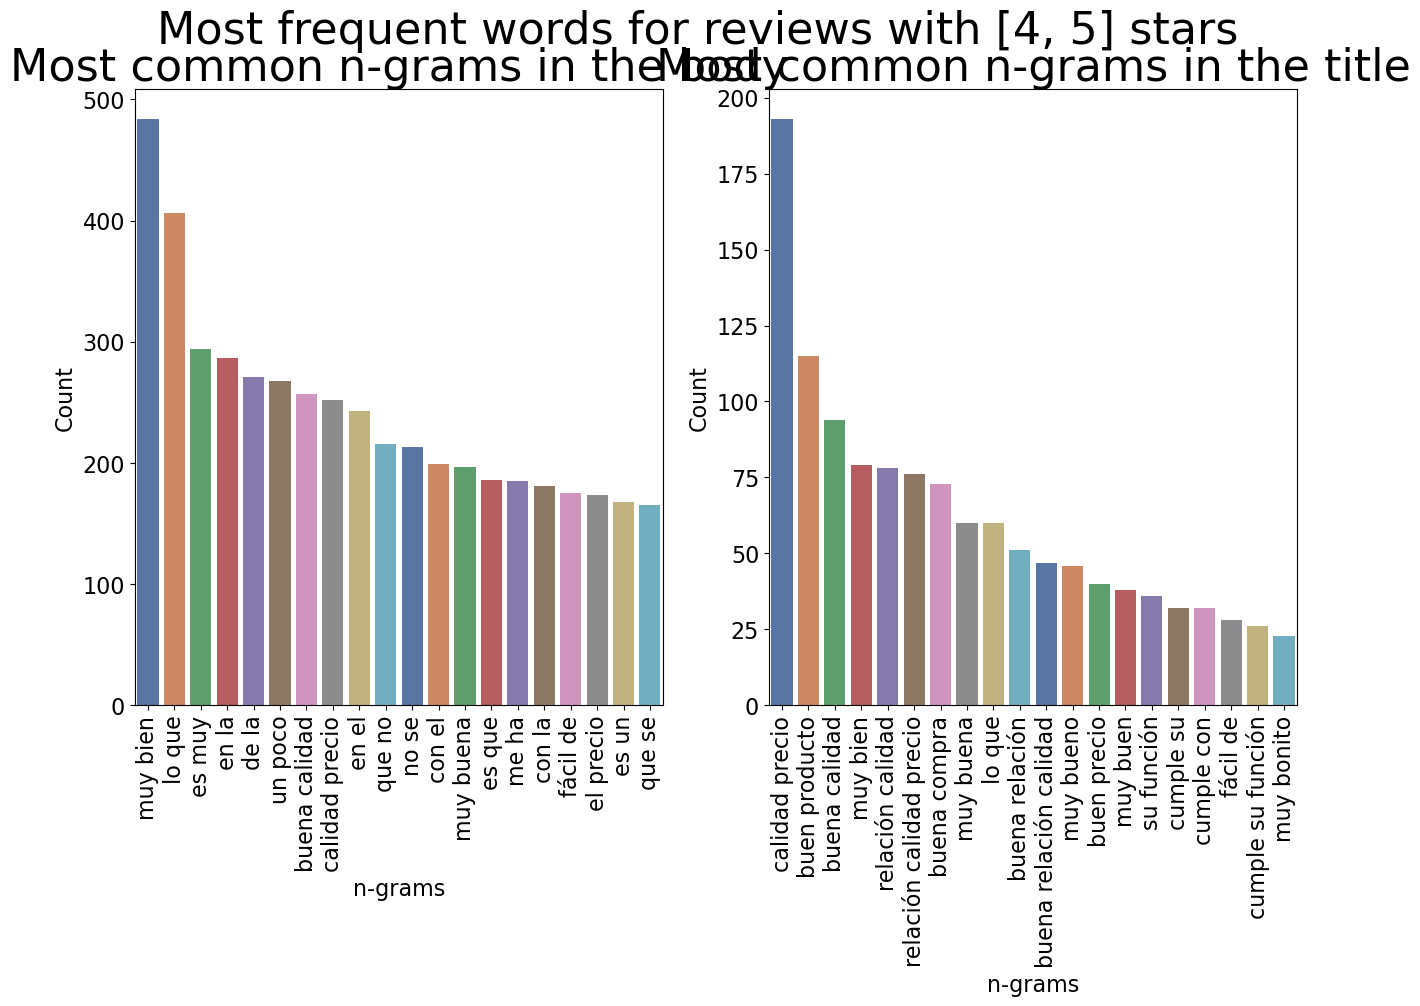

In [45]:
from amazon_review_score_predictor.plot import PlotParams
from amazon_review_score_predictor.transform import NLPUtils

best_reviews = sampled_reviews_train_data.copy()[sampled_reviews_train_data.stars.isin([4, 5])]

body_count = NLPUtils.count_common_words(df=best_reviews.review_body, ngram_range=(2, 3), max_count=20)
body_plot_params: PlotParams = {
  'x': body_count['labels'],
  'y': body_count['counts'],
  'hue': body_count['labels'],
  'title': 'Most common n-grams in the body',
  'xlabel': 'n-grams',
  'ylabel': 'Count',
  'labelrotation': 90,
}

title_count = NLPUtils.count_common_words(df=best_reviews.review_title, ngram_range=(2, 3), max_count=20)
title_plot_params: PlotParams = {
  'x': title_count['labels'],
  'y': title_count['counts'],
  'hue': title_count['labels'],
  'title': 'Most common n-grams in the title',
  'xlabel': 'n-grams',
  'ylabel': 'Count',
  'labelrotation': 90,
}

PlotUtils.create_comparison_plot(
  title='Most frequent words for reviews with [4, 5] stars',
  params=[title_plot_params, body_plot_params]
)

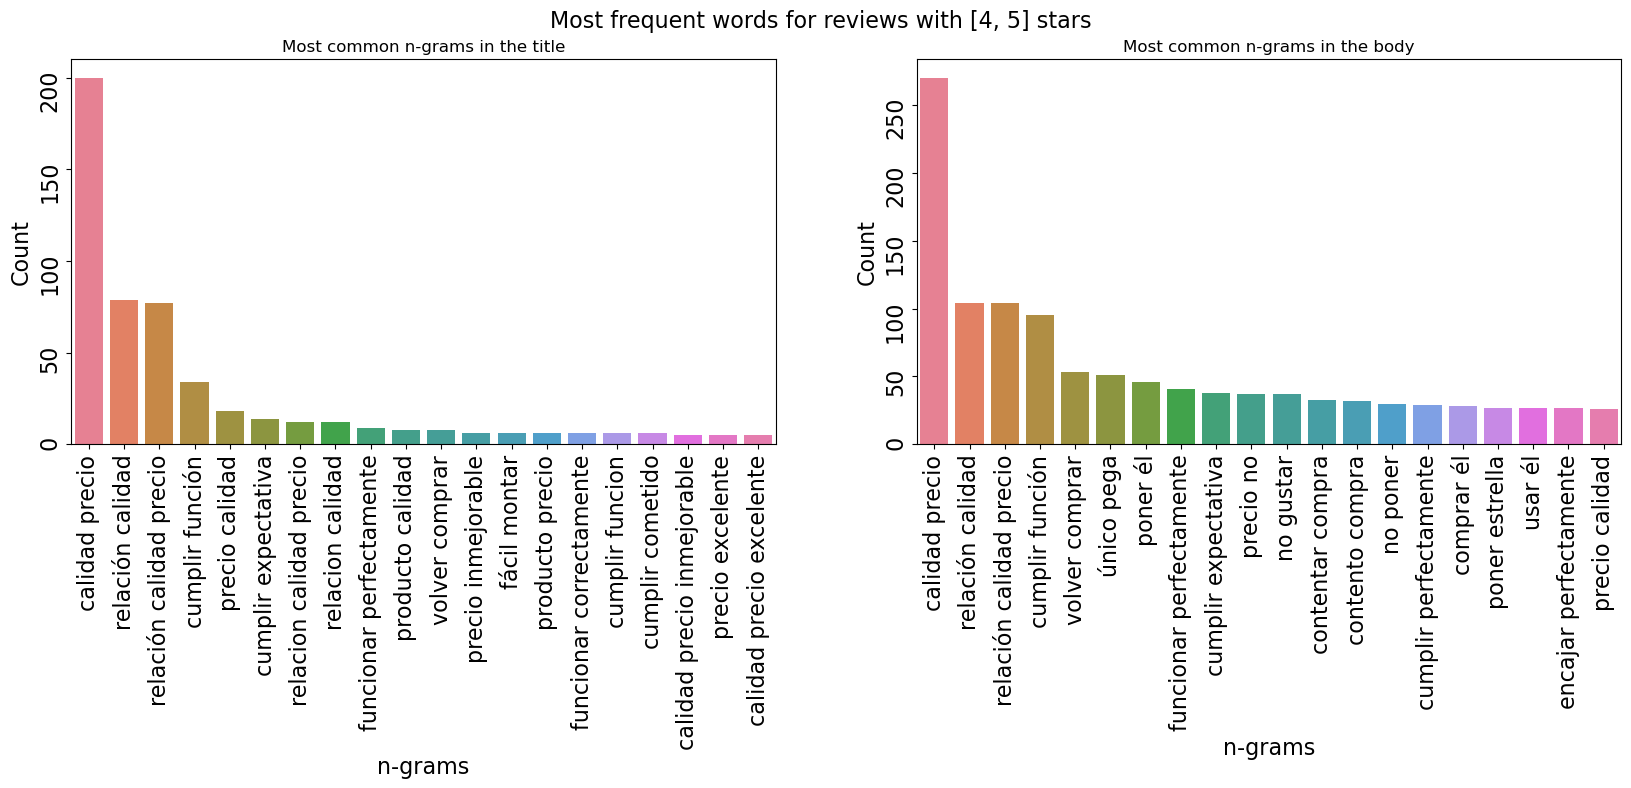

In [45]:
common_words_count(df=sampled_reviews_train_data, stars=[4,5], ngram_range=(2,3), max_count=20, fontsize=fontsize, figsize=(20, 5))

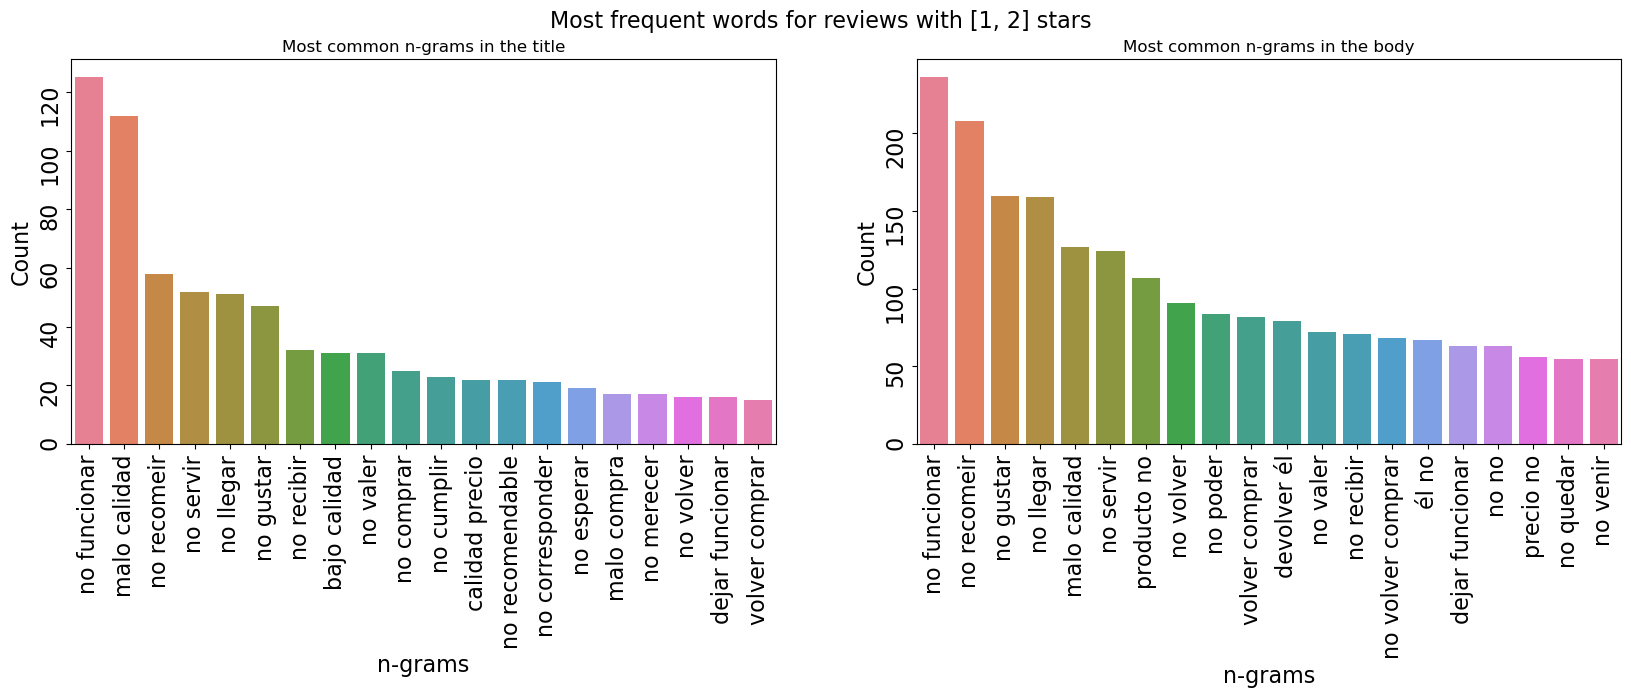

In [46]:
common_words_count(df=sampled_reviews_train_data, stars=[1,2], ngram_range=(2,3), max_count=20, fontsize=fontsize, figsize=(20, 5))

It can be noted that some n-grams such as `no gustar` and `preciar no` are shared between positive and negative reviews (in different proportions) but this is outside the scope of this study.

### Benchmark Model

As a benchmark model we will use:

* The bag of words method where a count of the words of the bodies of the reviews will be made.
* An `SVC` model.
* One vs Rest method for multi-class problems.

The strategy to be followed will be described below:

1. Only the text in the body of the review will be considered.
1. An instance of `CountVectorizer` will be created to process and vectorize the information from both` train` and `dev`.
1. The model `SVC` and` RandomForestClassifier` will be trained with the sample of the training data.
1. Once the training is finished, the `dev` data will be used to obtain the` accuracy` of the model.

In [23]:
# Create counter
benchmark_count_vectorizer = CountVectorizer(max_features = max_features, ngram_range=(1, 1))

# Transform
print("Vectorizing process:", end=" ")
%time matrix_body_train = benchmark_count_vectorizer.fit_transform(sampled_reviews_train_data.review_body)
X_train_bench = matrix_body_train.toarray()
y_train_bench = sampled_reviews_train_data.stars

Vectorizing process: Wall time: 176 ms


In [24]:
reviews_dev_data = pd.read_json("./data/dataset_es_dev.json", lines=True)

# Lemmatize
print("Body process:", end=" ")
%time reviews_dev_data.review_body = reviews_dev_data.review_body.apply(lemmatize_text)
print("Title process:", end=" ")
%time reviews_dev_data.review_title = reviews_dev_data.review_title.apply(lemmatize_text)

reviews_dev_data = reviews_dev_data[["review_title", "review_body", "stars"]]

Body process: Wall time: 51.9 s
Title process: Wall time: 33.4 s


In [25]:
print("Vectorizing process:", end=" ")
%time matrix_body_dev = benchmark_count_vectorizer.transform(reviews_dev_data.review_body)
X_dev_bench = matrix_body_dev.toarray()
y_dev_bench = reviews_dev_data.stars

Vectorizing process: Wall time: 85 ms


Below are two functions that will be useful to visualize the results and train the models:

In [26]:
# Plot confusion matrix
def confusion_multi(ytest,y_pred):
    names = ["1","2", "3", "4", "5"]
    cm = confusion_matrix(ytest,y_pred)
    f,ax = plt.subplots(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidth=.5, linecolor="r", fmt=".0f", ax=ax)
    plt.xlabel("y_pred")
    plt.ylabel("y_true")
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)
    plt.show()

# Train model
def train_benchmark_model(model, traindata, devdata):
    X_train, y_train = traindata
    X_dev, y_dev = devdata

    # Training classifier
    print("Training", end=" ")
    start_time = time()
    model.fit(X_train, y_train)
    print_elapsed_minutes(start_time)

    # Predict
    print("Predicting", end=" ")
    start_time = time()
    predictions = model.predict(X_dev)
    print_elapsed_minutes(start_time)

    # Accuracy dev
    accuracy = accuracy_score(y_dev, predictions)
    print(f"Accuracy for dev set: {100 * accuracy:.2f}%")

    confusion_multi(y_dev, predictions)

We execute the function to train and obtain the results of the model:

Training 4.04 min
Predicting 3.69 min
Accuracy for dev set: 41.76%


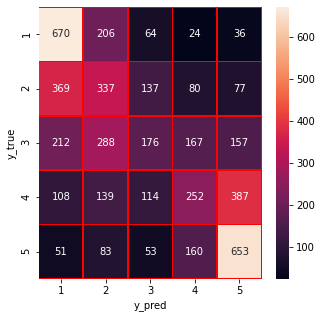

In [27]:
# # One vs Rest + SVC
train_benchmark_model(OneVsRestClassifier(SVC(random_state=random_state), n_jobs=-1), (X_train_bench, y_train_bench), (X_dev_bench, y_dev_bench))

Training 1.02 min
Predicting 0.02 min
Accuracy for dev set: 39.30%


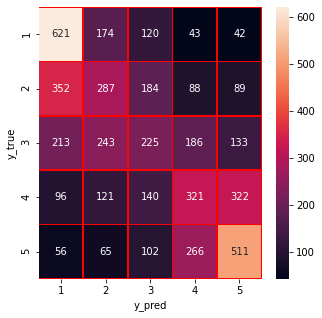

In [28]:
# One vs Rest + Random Forest
train_benchmark_model(OneVsRestClassifier(RandomForestClassifier(random_state=random_state, n_jobs=-1), n_jobs=-1), (X_train_bench, y_train_bench), (X_dev_bench, y_dev_bench))

As **benchmark** it will be taken:

* Model: `SVC` with default values.
* Accuracy obtained: `41%`.

### Creation of the model and optimization of hyperparameters.

Considering the hardware resources available at the time of this analysis, the following steps will be followed:

1. The training data to be used will be the sample of 10,000 records previously obtained. They will be used for the optimization of hyperparameters.
1. Both the `SVC` and` RandomForestClassifier` models will be studied.
1. For vectorization, the classes `CountVectorizer` and` TfidfVectorizer` will be implemented.

Due to the large volume of data and to monitor the training time for each combination during the hyperparameter optimization phase, instead of using models like `GridSearchCV` we will use:

* `for` cycles.
* Hypermarameters will be optimized by training with `train` and validating with` dev`.
* The actual `accuracy` of the model will be estimated comparing with the` test` data.

Here are two methods:

* `confusion_binary` that will help us at the end of the analysis.
* `train_model` adaptation of` train_benchmark_model` to be able to contemplate the cases mentioned previously in this list.

In [29]:
def confusion_binary(ytest,y_pred):
    names = ["0","1"]
    cm = confusion_matrix(ytest,y_pred)
    f,ax = plt.subplots(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidth=.5, linecolor="r", fmt=".0f", ax=ax)
    plt.xlabel("y_pred")
    plt.ylabel("y_true")
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)
    plt.show()

def train_model(data, classifier, title_vectorizer, body_vectorizer, return_results=True, print_confusion_matrix=False, binary=False):
    start_time = time()
    
    train_data, dev_data = data
    title_words_train = title_vectorizer.fit_transform(train_data.review_title)
    body_words_train = body_vectorizer.fit_transform(train_data.review_body)
    
    X_train = sparse.hstack((title_words_train, body_words_train)) 
    y_train = train_data.stars

    # model generation
    classifier.fit(X_train, y_train)

    title_words_dev = title_vectorizer.transform(dev_data.review_title)
    body_words_dev = body_vectorizer.transform(dev_data.review_body)

    X_dev = sparse.hstack((title_words_dev, body_words_dev))
    y_dev = dev_data.stars

    # Predict
    predictions = classifier.predict(X_dev)
    print_elapsed_minutes(start_time)
    
    # Accuracy dev
    accuracy = accuracy_score(y_dev, predictions)
    print(f"Accuracy for dev set: {100 * accuracy:.2f}%\n")

    if print_confusion_matrix:
        confusion_binary(y_dev, predictions) if binary else confusion_multi(y_dev, predictions)

    if return_results:
        return accuracy

Starting the analysis for the `SVC` model:

In [30]:
ngram_ranges = [(1,1), (1,2)]
Cs=[1.0, 2.0]
kernels=["linear", "rbf"]
degrees=[2, 3]
vectorizer_strategies = ["count", "tf_idf"]
combinations = []
best_params_svc = {
    "accuracy": 0
}

for ngram_range in ngram_ranges:
    for C in Cs:
        for kernel in kernels:
            for degree in degrees:
                for vectorizer_strategy in vectorizer_strategies:
                    combinations.append({
                        "ngram_range": ngram_range,
                        "C": C,
                        "kernel": kernel,
                        "degree": degree,
                        "vectorizer_strategy": vectorizer_strategy
                    })

total_combinations = len(combinations)
for loop_number, combination in enumerate(combinations):
    print(f"Loop {loop_number + 1}/{total_combinations} ({combination}) =>", end=" ")
    
    if combination["vectorizer_strategy"] == "tf_idf":
        body_vectorizer = TfidfVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
        title_vectorizer = TfidfVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
    else:
        body_vectorizer = CountVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
        title_vectorizer = CountVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
    
    classifier = OneVsRestClassifier(SVC(C=combination["C"], kernel=combination["kernel"], degree=combination["degree"], random_state=random_state), n_jobs=-1)
    model_accuracy = train_model((sampled_reviews_train_data, reviews_dev_data), classifier, title_vectorizer, body_vectorizer)
    
    if best_params_svc["accuracy"] < model_accuracy:
        best_params_svc["accuracy"] = model_accuracy
        best_params_svc["params"] = combination
        best_params_svc["classifier"] = classifier
        best_params_svc["body_vectorizer"] = body_vectorizer
        best_params_svc["title_vectorizer"] = title_vectorizer

print("\nBest Params:")
best_params_svc

Loop 1/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'linear', 'degree': 2, 'vectorizer_strategy': 'count'}) => 0.41 min
Accuracy for dev set: 43.38%

Loop 2/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'linear', 'degree': 2, 'vectorizer_strategy': 'tf_idf'}) => 0.31 min
Accuracy for dev set: 44.62%

Loop 3/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'linear', 'degree': 3, 'vectorizer_strategy': 'count'}) => 0.40 min
Accuracy for dev set: 43.38%

Loop 4/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'linear', 'degree': 3, 'vectorizer_strategy': 'tf_idf'}) => 0.31 min
Accuracy for dev set: 44.62%

Loop 5/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'rbf', 'degree': 2, 'vectorizer_strategy': 'count'}) => 0.55 min
Accuracy for dev set: 44.34%

Loop 6/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'rbf', 'degree': 2, 'vectorizer_strategy': 'tf_idf'}) => 0.56 min
Accuracy for dev set: 45.66%

Loop 7/32 ({'ngram_range': (1, 1), 'C': 1.0, 'kernel': 'rbf', 'degree': 3, 'vectorize

{'accuracy': 0.4586,
 'params': {'ngram_range': (1, 2),
  'C': 1.0,
  'kernel': 'rbf',
  'degree': 2,
  'vectorizer_strategy': 'tf_idf'},
 'classifier': OneVsRestClassifier(estimator=SVC(degree=2, random_state=1990), n_jobs=-1),
 'body_vectorizer': TfidfVectorizer(max_features=2000, ngram_range=(1, 2)),
 'title_vectorizer': TfidfVectorizer(max_features=2000, ngram_range=(1, 2))}

Continuing with `RandomForestClassifier`:

In [31]:
ngram_ranges = [(1,1), (1,2)]
n_estimators_array = [100, 200]
criterions = ["gini", "entropy"]
max_depths = [10, 50, 100]
vectorizer_strategies = ["count", "tf_idf"]
combinations = []
best_params_random_forest = {
    "accuracy": 0
}

for n_estimators in n_estimators_array:
    for criterion in criterions:
        for max_depth in max_depths:
            for ngram_range in ngram_ranges:
                for vectorizer_strategy in vectorizer_strategies:
                    combinations.append({
                        "n_estimators": n_estimators,
                        "criterion": criterion,
                        "max_depth": max_depth,
                        "ngram_range": ngram_range,
                        "vectorizer_strategy": vectorizer_strategy
                    })

total_combinations = len(combinations)
for loop_number, combination in enumerate(combinations):
    print(f"Loop {loop_number + 1}/{total_combinations} ({combination}) =>", end=" ")

    if combination["vectorizer_strategy"] == "tf_idf":
        body_vectorizer = TfidfVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
        title_vectorizer = TfidfVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
    else:
        body_vectorizer = CountVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])
        title_vectorizer = CountVectorizer(max_features = max_features, ngram_range=combination["ngram_range"])

    classifier = OneVsRestClassifier(RandomForestClassifier(max_depth=combination["max_depth"], criterion=combination["criterion"], n_estimators=combination["n_estimators"], n_jobs=-1, random_state=random_state), n_jobs=-1)
    model_accuracy = train_model((sampled_reviews_train_data, reviews_dev_data), classifier, title_vectorizer, body_vectorizer)

    if best_params_random_forest["accuracy"] < model_accuracy:
        best_params_random_forest["accuracy"] = model_accuracy
        best_params_random_forest["params"] = combination
        best_params_random_forest["classifier"] = classifier
        best_params_random_forest["body_vectorizer"] = body_vectorizer
        best_params_random_forest["title_vectorizer"] = title_vectorizer

print("\nBest Params for Random Forest:")
best_params_random_forest

Loop 1/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 10, 'ngram_range': (1, 1), 'vectorizer_strategy': 'count'}) => 0.03 min
Accuracy for dev set: 42.32%

Loop 2/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 10, 'ngram_range': (1, 1), 'vectorizer_strategy': 'tf_idf'}) => 0.03 min
Accuracy for dev set: 42.76%

Loop 3/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 10, 'ngram_range': (1, 2), 'vectorizer_strategy': 'count'}) => 0.03 min
Accuracy for dev set: 42.62%

Loop 4/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 10, 'ngram_range': (1, 2), 'vectorizer_strategy': 'tf_idf'}) => 0.03 min
Accuracy for dev set: 42.08%

Loop 5/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 50, 'ngram_range': (1, 1), 'vectorizer_strategy': 'count'}) => 0.05 min
Accuracy for dev set: 44.58%

Loop 6/48 ({'n_estimators': 100, 'criterion': 'gini', 'max_depth': 50, 'ngram_range': (1, 1), 'vectorizer_strategy': 'tf_idf'}) => 0.05 min
Accuracy for 

{'accuracy': 0.4498,
 'params': {'n_estimators': 200,
  'criterion': 'entropy',
  'max_depth': 50,
  'ngram_range': (1, 1),
  'vectorizer_strategy': 'count'},
 'classifier': OneVsRestClassifier(estimator=RandomForestClassifier(criterion='entropy',
                                                      max_depth=50,
                                                      n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=1990),
                     n_jobs=-1),
 'body_vectorizer': CountVectorizer(max_features=2000),
 'title_vectorizer': CountVectorizer(max_features=2000)}

It can be observed:

* The performance of the model `SVC` (45.86%) was better than `RandomForestClassifier` (44.98%). However, their difference does not exceed 1%.
* The training and validation execution time with the `SVC` model is approximately 14 times greater than `RandomForestClassifier`.

Taking into account the aforementioned, the model to choose to train the model with the complete training data will be **`RandomForestClassifier`**. This is due to the speed-performance trade-off (in production, less computing time implies more money savings).

Training with the complete dataset using the chosen hyperparameters:

In [32]:
best_params_random_forest

{'accuracy': 0.4498,
 'params': {'n_estimators': 200,
  'criterion': 'entropy',
  'max_depth': 50,
  'ngram_range': (1, 1),
  'vectorizer_strategy': 'count'},
 'classifier': OneVsRestClassifier(estimator=RandomForestClassifier(criterion='entropy',
                                                      max_depth=50,
                                                      n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=1990),
                     n_jobs=-1),
 'body_vectorizer': CountVectorizer(max_features=2000),
 'title_vectorizer': CountVectorizer(max_features=2000)}

Training time: 9.05 min
Accuracy for dev set: 48.18%



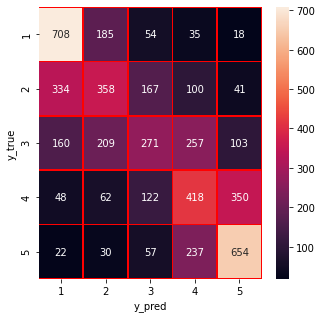

In [33]:
rf_best_params = best_params_random_forest["params"]
rf_body_vectorizer = CountVectorizer(max_features = max_features, ngram_range=rf_best_params["ngram_range"])
rf_title_vectorizer = CountVectorizer(max_features = max_features, ngram_range=rf_best_params["ngram_range"])
rf_classifier = OneVsRestClassifier(RandomForestClassifier(max_depth=rf_best_params["max_depth"], criterion=rf_best_params["criterion"], n_estimators=rf_best_params["n_estimators"], n_jobs=-1, random_state=random_state), n_jobs=-1)
print("Training time:", end=" ")
train_model((reviews_train_data, reviews_dev_data), rf_classifier, rf_title_vectorizer, rf_body_vectorizer, return_results=False, print_confusion_matrix=True)

Estimating the actual `accuracy` of the model with the `test` data set:

Body process: Wall time: 1min 8s
Title process: Wall time: 39.3 s
Predict: 0.02 min
Accuracy for test set: 48.28%



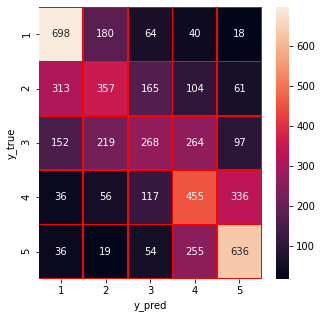

In [34]:
# Import
reviews_test_data = pd.read_json("./data/dataset_es_test.json", lines=True)

# Process
print("Body process:", end=" ")
%time reviews_test_data.review_body = reviews_test_data.review_body.apply(lemmatize_text)
print("Title process:", end=" ")
%time reviews_test_data.review_title = reviews_test_data.review_title.apply(lemmatize_text)
reviews_test_data = reviews_test_data[["review_title", "review_body", "stars"]]

title_words_test = rf_title_vectorizer.transform(reviews_test_data.review_title)
body_words_test = rf_body_vectorizer.transform(reviews_test_data.review_body)

X_test = sparse.hstack((title_words_test, body_words_test))
y_test = reviews_test_data.stars

# Predict
print("Predict:", end=" ")
start_time = time()
predictions = rf_classifier.predict(X_test)
print_elapsed_minutes(start_time)

# Evaluation
accuracy_test = accuracy_score(y_test, predictions)
print(f"Accuracy for test set: {100 * accuracy_test:.2f}%\n")

confusion_multi(y_test, predictions)

In this case we obtain an accuracy of approximately `48%` for the prediction model.

Using the properties of the algorithm class, it can be obtain the words that are most useful to make predictions. Below, it can be seen the most used words to predict the cases of 1 and 5 stars respectively:

In [35]:
all_body_words = [f"{word} (body)" for word in rf_body_vectorizer.get_feature_names()]
all_title_words = [f"{word} (title)" for word in rf_title_vectorizer.get_feature_names()]
all_words = [*all_title_words, *all_body_words]

def plot_feature_importance(all_words, importances, use_case):
    indices = np.argsort(importances)[::-1]
    indices = indices[:30]
    selected_words = [all_words[i] for i in indices]
    selected_importances = importances[indices]

    plt.figure(figsize = (15,8))
    g = sns.barplot(x=selected_words, y=selected_importances)
    g.set_title(f"Most relevant words for predicting {use_case}", fontsize=fontsize)
    g.set_xlabel("Words", fontsize=fontsize)
    g.set_ylabel("Importance", fontsize=fontsize)
    g.tick_params(axis="x", labelsize=fontsize, labelrotation=80)
    plt.show()

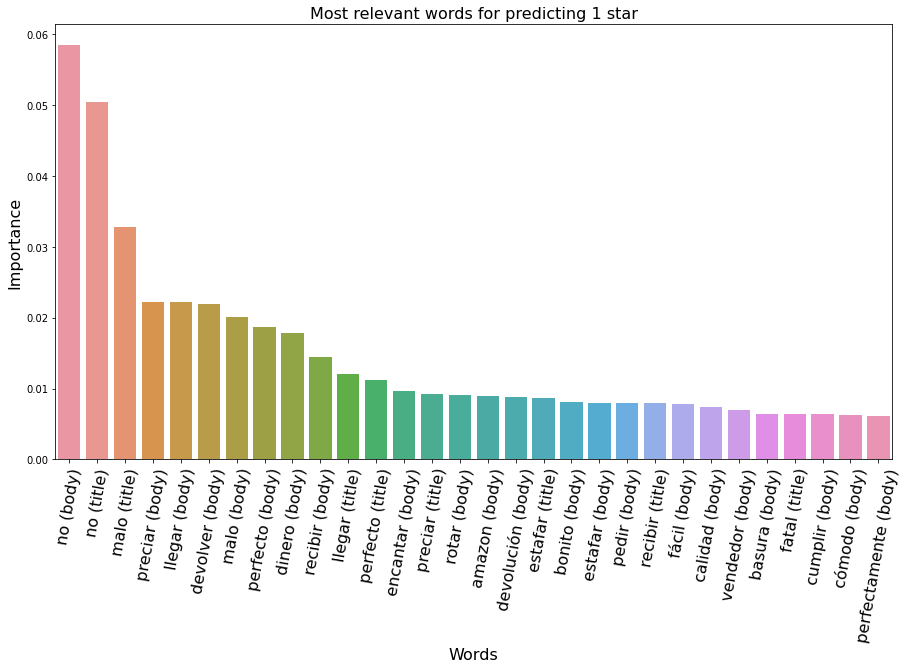

In [36]:
importances = rf_classifier.estimators_[0].feature_importances_

plot_feature_importance(all_words, importances, "1 star")

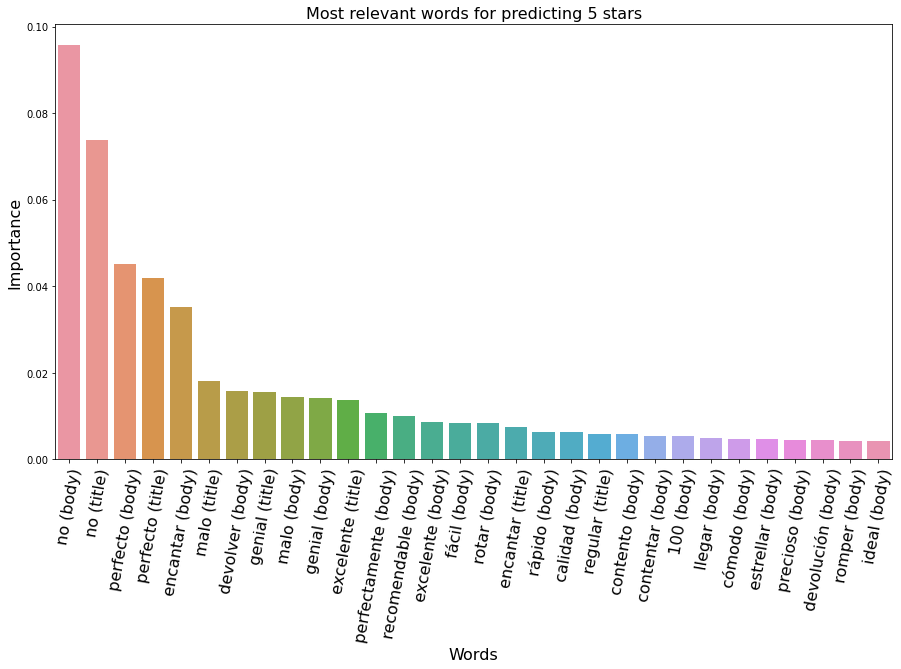

In [37]:
importances = rf_classifier.estimators_[4].feature_importances_

plot_feature_importance(all_words, importances, "5 stars")

It can be seen that indeed the first graph focuses on negative words (1-star review) and the second on words that could be considered positive (5-star review). However, it should also be noted that both plots have some coincidences so the model confusion in the matrix can be explained.

Something interesting can be observed in the confusion matrix of the `test` set. The algorithm "confuses" to a greater extent, the grades 4 and 5 and the 1 and 2.
This may lead to think that it may make sense to change focus and instead of treating the problem as multi-class, treat it as binary (positive reviews vs negative reviews).

To do this, reviews with 3 stars will be eliminated and reviews with 4 and 5 stars will be grouped as positive and 1 and 2 as negative.

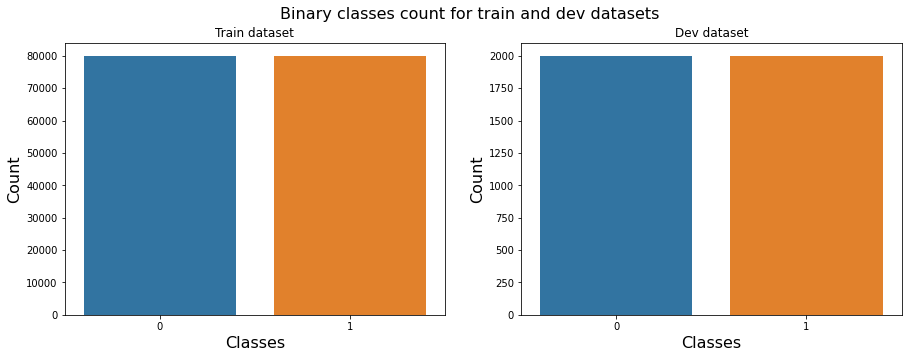

In [38]:
binary_train_data = reviews_train_data[reviews_train_data.stars.isin([1, 2, 4, 5])].copy()
binary_train_data.stars.replace([1,2,4,5], [1,1,0,0], inplace=True)

binary_dev_data = reviews_dev_data[reviews_dev_data.stars.isin([1, 2, 4, 5])].copy()
binary_dev_data.stars.replace([1,2,4,5], [1,1,0,0], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle(f"Binary classes count for train and dev datasets", fontsize=fontsize)


g = sns.countplot(x="stars", data=binary_train_data, ax=axes[0])
g.set_xlabel("Classes", fontsize=fontsize)
g.set_ylabel("Count", fontsize=fontsize)
axes[0].set_title("Train dataset")

g = sns.countplot(x="stars", data=binary_dev_data, ax=axes[1])
g.set_xlabel("Classes", fontsize=fontsize)
g.set_ylabel("Count", fontsize=fontsize)
axes[1].set_title("Dev dataset")

plt.show()

Starting the training:

Training time: 1.48 min
Accuracy for dev set: 86.40%



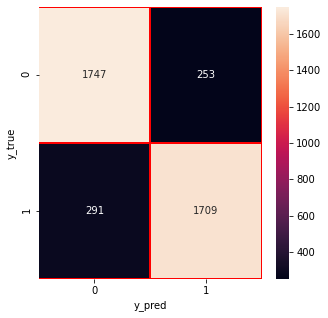

In [39]:
binary_body_vectorizer = CountVectorizer(max_features = max_features, ngram_range=rf_best_params["ngram_range"])
binary_title_vectorizer = CountVectorizer(max_features = max_features, ngram_range=rf_best_params["ngram_range"])
binary_random_forest = RandomForestClassifier(max_depth=rf_best_params["max_depth"], criterion=rf_best_params["criterion"], n_estimators=rf_best_params["n_estimators"], n_jobs=-1, random_state=random_state)
print("Training time:", end=" ")
train_model((binary_train_data, binary_dev_data), binary_random_forest, binary_title_vectorizer, binary_body_vectorizer, return_results=False, print_confusion_matrix=True, binary=True)

For the `test` set:

In [40]:
all_body_words_binary = [f"{word} (body)" for word in binary_body_vectorizer.get_feature_names()]
all_title_words_binary = [f"{word} (title)" for word in binary_title_vectorizer.get_feature_names()]
all_words_binary = [*all_title_words_binary, *all_body_words_binary]

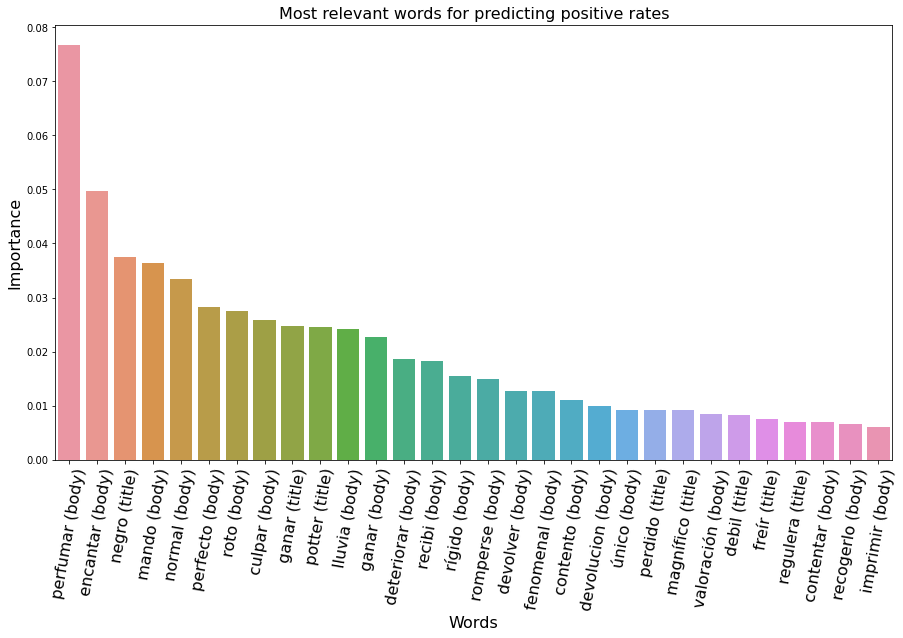

In [41]:
importances = binary_random_forest.estimators_[0].feature_importances_

plot_feature_importance(all_words, importances, "positive rates")

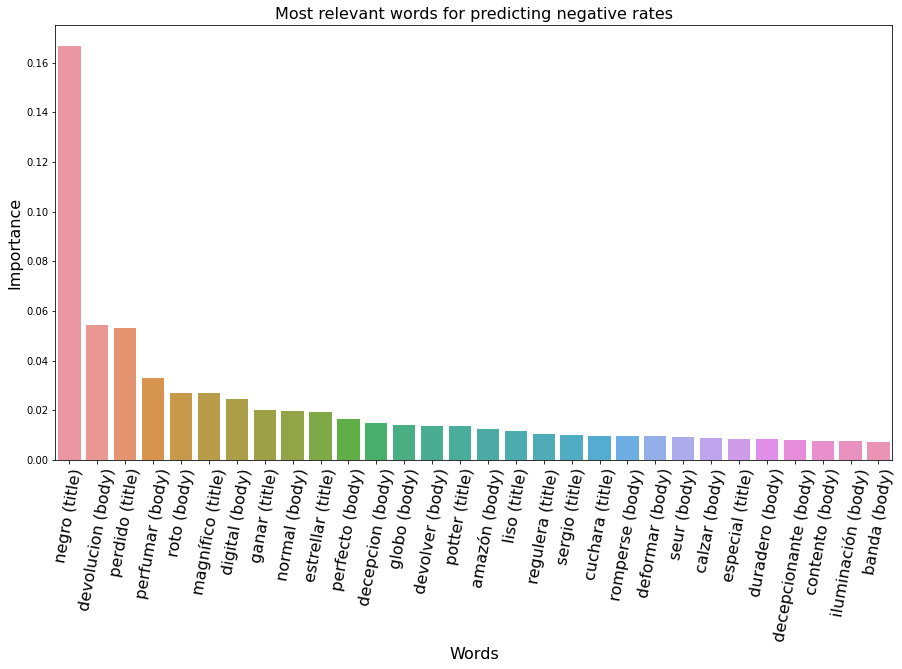

In [42]:
importances = binary_random_forest.estimators_[1].feature_importances_

plot_feature_importance(all_words, importances, "negative rates")

### Results Analysis

A brief summary may be of help to compare the results obtained with what is expected:

* **The problem:** Predict the stars for a review regarding its content.
* **Expected results:** Obtain a model that can predict the number of stars that a user can assign to a purchase from their review. To do this, it is expected to associate words with a positive connotation (perfect, wonderful, delivered, etc.) with high marks like 4 and 5 and negative words (bad, lost, faulty, etc.) with low marks like 1 and 2.

The Random Forest model and the One vs Rest strategy provide 5 models, each of them dedicated to focusing on each rating. In the plots `Most relevant words for predicting 1 star` and` Most relevant words for predicting 5 stars`, we can see the predominance of words with negative connotation (return, cheat or fatal) and positive (perfect, great or excellent), respectively . However, considering that the comparison deals with the two extreme scores, the differences were expected to be much more marked. There are unexpected words like "perfect" in the negatives and "bad" in the positives ones. These coincidences between both models explain the `accuracy` obtained (`48%`).

One might also hope that the body of the review serves better as a guide for classification, which agrees with the results plotted. It must not be forgotten that in high positions of importance, some words in particular carry considerable weight if they are found in the title as 'perfect' or 'not'.

Another expected result is, if the perspective of the problem is changed, and it is thought of as a binary one (positive vs negative reviews), the level of successes would increase. The confusion matrix resulting from the multi-class problem hints that this may be true since the confusions are mostly concentrated in regions 4 and 5 (positive) and 1 and 2 (negative). Making adjustments to convert the problem to a binary one gives a significant increase in the accuracy to 86%, thus confirming our hypothesis.

### Conclusions

* The best model obtained was `RandomForestClassifier` with the following hyperparameters:
    * `n_estimators`: 200.
    * `criterion`: 'entropy'.
    * `max_depth`: 50.
* For vectorization, the `Bag of Words` strategy performed better than the `TF-IDF` with Random Forest. In this case with monograms.
* The estimated performance of the model is `48%` of correctness (`accuracy`).
* An [article](https://arxiv.org/pdf/2010.02573v1.pdf) published on this dataset, indicates that using an algorithm called `BERT` and a training of approximately `10hrs`, an `accuracy` of `58%` can be obtained so the analysis presented in this notebook can be improved by making use of more advanced models.
* The confusion matrix gives clues that indicate that the problem can be treated as binary: positive (4 and 5) and negative (1 and 2) reviews. By doing this, it can be noticed a significant improvement in the `accuracy` from `48%` to `86%`.
* The Random Forest model makes it much easier for us to interpret the results obtained. In the graphs of the most important words for making predictions, it can be seen that for negative cases, words that can be associated with negative feelings predominate. The same can be said for the case of positive reviews.
* An additional point to consider in the plots of the most important words for the prediction are the coincidences (although in different proportions) for the positive and negative reviews such as `devolucion`, `normal` or `perfecto` that may be causing the confusion of the model.
* Possible improvements that can be implemented on this analysis:
    * The use of the multi-class strategy `One vs One`.
    * Investigate the effect on model performance by more rigorously filtering words (example: removing the word `no` from positive reviews).
    * Include in the model the categories of the reviews.
    * Investigate and apply more advanced models (such as neural networks).